In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/riya/OneDrive/project/Disease-Outbreak-Prediction-Platform/data/raw_data.csv")

df.head()

,id,week_of_outbreak,state_ut,district,Disease,Cases,Deaths,day,month,year,Latitude,Longitude,precipitation,LAI,Temp
0,0,1st week,Meghalaya,East Jaintia Hills,Acute Diarrhoeal Disease,160,NaN,2,1,2022,25.251576,92.484050,0.020354,34.5,291.533333
1,1,2nd week,Maharashtra,Gadchiroli,Malaria,7,2.0,10,1,2022,19.759070,80.162281,0.007479,9.0,299.970000
2,2,3rd week,Tamil Nadu,Pudukottai,Acute Diarrhoeal Disease,8,NaN,18,1,2022,10.382651,78.819126,0.107413,12.0,300.766667
3,3,3rd week,Gujarat,Patan,Acute Diarrhoeal Disease,7,NaN,11,1,2022,23.774057,71.683735,0.065094,9.0,299.080000
4,4,3rd week,Kerala,Ernakulam,Acute Diarrhoeal Disease,14,NaN,24,12,2021,9.984080,76.274146,0.041256,33.0,303.028000


In [50]:
print(df.shape)

(8985, 15)


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8985 entries, 0 to 8984
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                8985 non-null   int64  
 1   week_of_outbreak  8985 non-null   object 
 2   state_ut          8985 non-null   object 
 3   district          8985 non-null   object 
 4   Disease           8985 non-null   object 
 5   Cases             8985 non-null   object 
 6   Deaths            2554 non-null   float64
 7   day               8985 non-null   int64  
 8   month             8985 non-null   int64  
 9   year              8985 non-null   int64  
 10  Latitude          8985 non-null   float64
 11  Longitude         8985 non-null   float64
 12  precipitation     8849 non-null   float64
 13  LAI               6790 non-null   float64
 14  Temp              8047 non-null   float64
dtypes: float64(6), int64(4), object(5)
memory usage: 1.0+ MB


In [52]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
}).sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Deaths,6431,71.574847
LAI,2195,24.429605
Temp,938,10.439622
precipitation,136,1.513634
id,0,0.000000
week_of_outbreak,0,0.000000
state_ut,0,0.000000
district,0,0.000000
Disease,0,0.000000
Cases,0,0.000000


In [53]:
df["Deaths"] = (
    df.groupby("district")["Deaths"]
    .transform(
        lambda x: x.fillna(x.median())
    )
)

df["Deaths"] = (
    df["Deaths"]
    .fillna(df["Deaths"].median())
)

df["Deaths"] = (
    df["Deaths"]
    .round()
    .astype("Int64")
)

In [54]:
cols = ["LAI", "Temp", "precipitation"]

df[cols] = (df.groupby(["district", "month"])[cols].transform(
        lambda x: x.fillna(x.median())
    )
)

df[cols] = (df[cols].fillna(df[cols].median()))

In [55]:
print(df.isnull().sum())

id                  0
week_of_outbreak    0
state_ut            0
district            0
Disease             0
Cases               0
Deaths              0
day                 0
month               0
year                0
Latitude            0
Longitude           0
precipitation       0
LAI                 0
Temp                0
dtype: int64


In [56]:
df

,id,week_of_outbreak,state_ut,district,Disease,Cases,Deaths,day,month,year,Latitude,Longitude,precipitation,LAI,Temp
0,0,1st week,Meghalaya,East Jaintia Hills,Acute Diarrhoeal Disease,160,1,2,1,2022,25.251576,92.484050,0.020354,34.5,291.533333
1,1,2nd week,Maharashtra,Gadchiroli,Malaria,7,2,10,1,2022,19.759070,80.162281,0.007479,9.0,299.970000
2,2,3rd week,Tamil Nadu,Pudukottai,Acute Diarrhoeal Disease,8,1,18,1,2022,10.382651,78.819126,0.107413,12.0,300.766667
3,3,3rd week,Gujarat,Patan,Acute Diarrhoeal Disease,7,1,11,1,2022,23.774057,71.683735,0.065094,9.0,299.080000
4,4,3rd week,Kerala,Ernakulam,Acute Diarrhoeal Disease,14,0,24,12,2021,9.984080,76.274146,0.041256,33.0,303.028000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8980,8980,52nd week,Tamil Nadu,Tiruvannamalai,Acute Diarrhoeal Disease,13,0,26,12,2009,12.227213,79.070156,0.250549,12.0,296.540000
8981,8981,52nd week,Uttarakhand,Dehradun,Cholera,4,0,24,12,2009,30.325565,78.043681,0.000626,12.0,288.960000
8982,8982,52nd week,Tamil Nadu,Dindigul,Dengue,9,0,14,12,2009,10.330330,78.067398,0.044519,10.0,301.576000
8983,8983,52nd week,Tamil Nadu,Trichy,Chikungunya,28,0,8,12,2009,10.799225,78.681142,0.182324,15.0,302.420000


In [57]:
print(df.isnull().sum().sum())

0


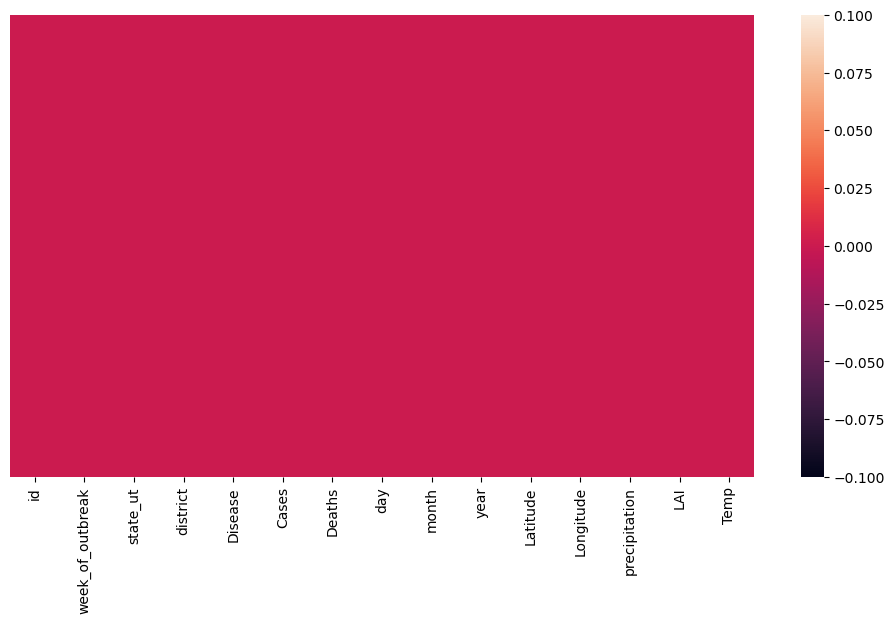

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True)
plt.show()

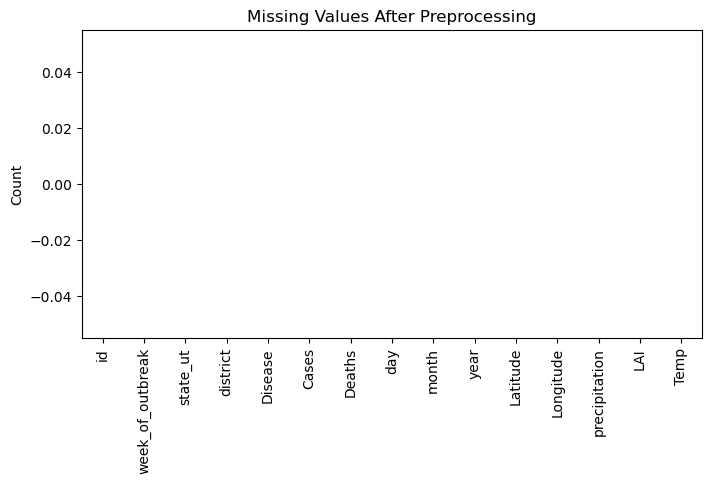

In [59]:
plt.figure(figsize=(8,4))

(df.isnull().sum()).plot(
    kind='bar',
    title='Missing Values After Preprocessing'
)

plt.ylabel('Count')
plt.show()

<Axes: xlabel='Cases', ylabel='Count'>

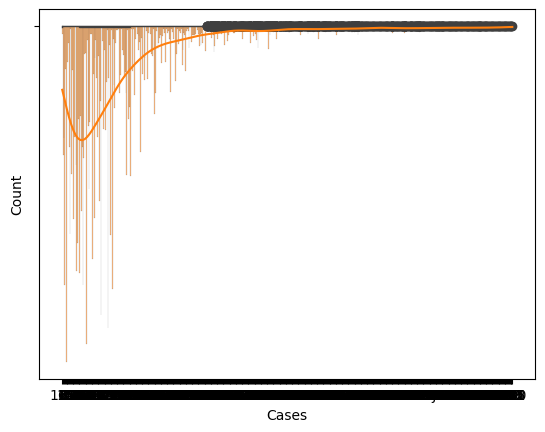

In [74]:
sns.boxplot(x=df['Cases'])
sns.histplot(df['Cases'], kde=True)

In [75]:
df.duplicated().sum()

np.int64(0)

In [76]:
df['Disease'].unique()

array(['Acute Diarrhoeal Disease', 'Malaria',
       'Acute Encephalitis Syndrome', 'Acute Gastroenteritis', 'Dengue',
       'pyrexia of unknown origin', 'Chikungunya', 'Cholera',
       'Malaria (PV)', 'Dengue Fever', 'Suspected Dengue',
       'Dengue Chikungunya', 'Dengue And Chikungunya',
       'Suspected Cholera', 'Diarrhea', 'Suspected Chikungunya',
       'Suspected Dengue And Chikungunya', 'Gastroenteritis',
       'Dengue And Malaria', 'Dengue/Chikungunya', 'Chikungunya/Dengue',
       'Chikungunya/ Dengue'], dtype=object)

In [77]:
disease_mapping = {
    # Diarrheal diseases
    'Acute Diarrhoeal Disease': 'Diarrheal Diseases',
    'Acute Gastroenteritis': 'Diarrheal Diseases',
    'Gastroenteritis': 'Diarrheal Diseases',
    'Diarrhea': 'Diarrheal Diseases',
    'Cholera': 'Diarrheal Diseases',
    'Suspected Cholera': 'Diarrheal Diseases',

    # Malaria
    'Malaria': 'Malaria',
    'Malaria (PV)': 'Malaria',

    # Dengue
    'Dengue': 'Dengue',
    'Dengue Fever': 'Dengue',
    'Suspected Dengue': 'Dengue',

    # Chikungunya
    'Chikungunya': 'Chikungunya',
    'Suspected Chikungunya': 'Chikungunya',

    # Dengue + Chikungunya
    'Dengue Chikungunya': 'Dengue-Chikungunya',
    'Dengue And Chikungunya': 'Dengue-Chikungunya',
    'Suspected Dengue And Chikungunya': 'Dengue-Chikungunya',
    'Dengue/Chikungunya': 'Dengue-Chikungunya',
    'Chikungunya/Dengue': 'Dengue-Chikungunya',
    'Chikungunya/ Dengue': 'Dengue-Chikungunya',

    # Mixed infection
    'Dengue And Malaria': 'Dengue And Malaria',

    # Other
    'Acute Encephalitis Syndrome': 'Encephalitis',
    'pyrexia of unknown origin': 'Fever of Unknown Origin'
}

In [78]:
df['Disease_Category'] = df['Disease'].map(disease_mapping)

In [79]:
print(df['Disease_Category'].value_counts())

Disease_Category
Diarrheal Diseases         5896
Dengue                     1635
Chikungunya                 734
Malaria                     545
Encephalitis                111
Dengue-Chikungunya           60
Dengue And Malaria            3
Fever of Unknown Origin       1
Name: count, dtype: int64


In [80]:
df['district'].nunique()

791

In [81]:
df['state_ut'].nunique()

36

In [82]:
df['year'].min()

2009

In [83]:
df['year'].max()

2022

In [84]:
df['Cases'].describe()

count     8985
unique     523
top         15
freq       301
Name: Cases, dtype: object

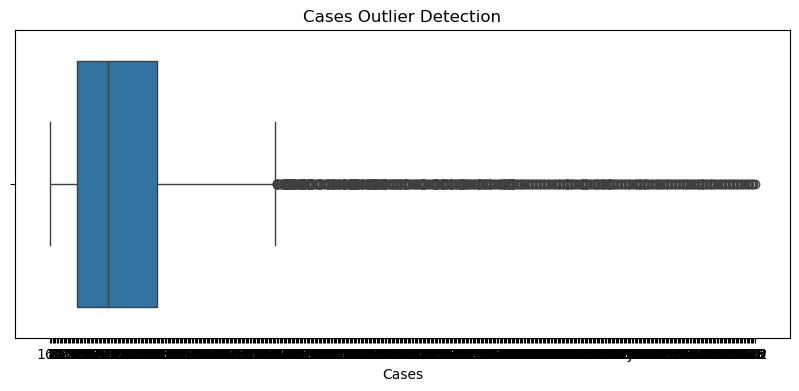

In [85]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df["Cases"]
)

plt.title("Cases Outlier Detection")
plt.show()

In [86]:
print(df[cols + ["Deaths"]].isnull().sum())
print(df.dtypes)

LAI              0
Temp             0
precipitation    0
Deaths           0
dtype: int64
id                    int64
week_of_outbreak     object
state_ut             object
district             object
Disease              object
Cases                object
Deaths                Int64
day                   int64
month                 int64
year                  int64
Latitude            float64
Longitude           float64
precipitation       float64
LAI                 float64
Temp                float64
Disease_Category     object
dtype: object


In [87]:
df.to_csv(
    "C:/Users/riya/OneDrive/project/Disease-Outbreak-Prediction-Platform/data/cleaned_data.csv",
    index=False
)